<a href="https://colab.research.google.com/github/bangjunhyuk1111/Machine-Learning/blob/Chapter-3/%EC%84%A0%ED%98%95_%ED%9A%8C%EA%B7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-최근접 이웃의 한계
앞에서 했던 K-최근접 이웃의 한계를 알아보기 위하여 다음과 같은 예를 살펴보겠다.

앞에서 했던 실습을 그래도 옮겨와서 모델을 훈련시켜 한계점에 대하여 이야기 해보자

In [15]:
# 앞에서 실습했던 내용
# 농어 데이터
import numpy as np
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

# 세트 분리 (인풋/타깃 배열지정, 각각 2개의 훈련/테스트 배열로 분리)
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state = 42)

# 분리한 인풋데이터는 1차원 배열이므로, 2차원 배열로 변경
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

# 모델 훈련
from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor()
knr.n_neighbors = 3
knr.fit(train_input, train_target)

# 길이가 50cm 인 농어의 무게 예측
print(knr.predict([[50]])) #바깥쪽 대괄호 []는 예측할 샘플의 목록을 나타내고, 안쪽 대괄호 [50]는 각 샘플의 특성(여기서는 농어의 길이 50cm)을 나타냅니다.

[1033.33333333]


# 한계점에 대해 들었던 나의 생각
일단 K-최근접 이웃의 특징이 값의 예측 방법이 이웃의 샘플들을 참고하여 구하는데,

데이터 샘플이 부족하여 예측하고자 하는 값의 이웃이 너무 멀리 있다면 뭔가 문제가 생길것이라 생각했다.

위에 데이터들을 살펴 보았을 때,

길이에 대한 무게의 샘플이 44까지 있는데,

내가 무게를 예측하고자 하는 농어의 길이가 100이라면 그에 알맞은 샘플은 43, 43.5, 44 이므로 완전히 잘못된 결과가 나올것이라 예측 했다.

또한, 길이가 50인 농어와 100인 농어의 무게가 똑같은 값으로 예측될 것이라고 생각했다.


# 실제 K-최근접 이웃의 한계점과 나의 생각 비교

학습된 모델을 통해 50, 100 농어의 무게를 예측하고 산점도로 나타내보자

In [16]:
print(knr.predict([[50], [100]]))

[1033.33333333 1033.33333333]


내가 이럴줄 알았다.

같은 결과가 나왔다.

아래에 산점도를 살펴보자

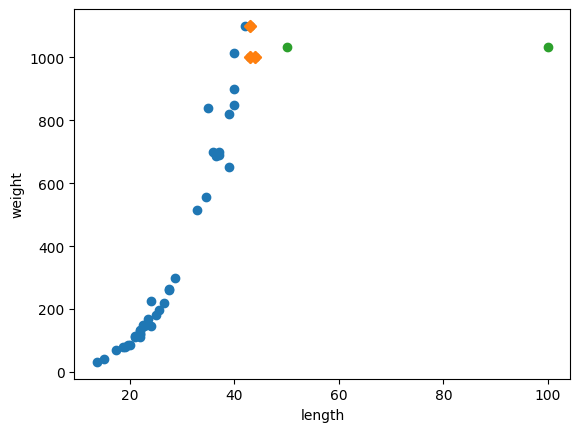

In [17]:
import matplotlib.pyplot as plt

#50, 100 농어의 이웃 데이터
distances, indexes = knr.kneighbors([ [50], [100]])

# 훈련 세트 산점도
plt.scatter(train_input, train_target)

# 이웃 다시 그리기
plt.scatter(train_input[indexes], train_target[indexes], marker = 'D')

# 50, 100 농어 그리기
plt.scatter([50, 100], knr.predict([[50], [100]]), marker = 'o')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

# 한계가 드러난 산점도 분석

예상대로 50, 100 농어 모두 근접한 3개의 이웃이 같음을 볼수 있고 이러한 점은 K-최근접 이웃의 한계점이라고 볼수있다.

농어가 아무리 커져도 모두 같은 결과가 나오기 때문이다.

새로운 훈련 세트를 계속 추가해 가는것은 별로 효율적이지 않고 번거로울거 같다.

이를 해결할 수 있는 알고리즘이 **선형 회귀** 이다.

# 선형 회귀

특성이 하나인 경우 어떤 직선을 학습하는 알고리즘이다.

사이킷런은 sklearn.linear_model 패키지 아래에 LinearRegression 클래스로 선형 회귀 알고리즘을 구현해 두었고 이전에 썻던 훈련, 평가, 예측하는 메서드 fit(), score(), predict() 는 모두 동일하게 사용가능하다.


# 저 위에 있는 농어 데이터를 토대로 선형 회귀 학습

In [18]:
# 선형 회귀 학습
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

# 모델 훈련
lr.fit(train_input, train_target)

# 훈련 모델 바탕으로 이전에 한계였던 50, 100 농어의 무게 예측
print(lr.predict([ [50], [100] ]))

[1241.83860323 3192.69585141]


음 이전에 K-최근접 이웃 회귀 알고리즘 에서는 둘이 같은 값이 나왔었지만 선형 회귀 알고리즘을 통해 얻은 값으론 둘의 차이가 크게 나는 것을 보니 학습이 잘 이루어 진듯 하다.

# 어떻게 이러한 값이 예측이 되었을까??

아래에서 원리를 이해하고 산점도 위에 그래프도 그려보자

일단 직선의 방정식은,

**y = a(기울기) * x + b(절편)** 이고,

(여기서는 y = 농어 무게, x = 농어 길이)

농어의 길이를 통해 예측을 할 때 무게를 에측할려면 a와 b를 구해야하는데,

이것은 LinearRegression 클래스를 통해 구하며,

**coef_ 와 intercept_** 속성에 저장되어 있다.

In [19]:
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535477


# 구한 기울기와 절편을 바탕으로 훈련 세트 산점도 위에 그래프 그리기

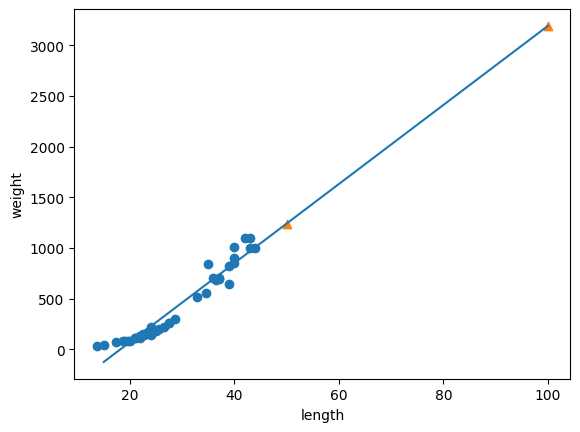

In [20]:
import matplotlib.pyplot as plt

plt.scatter(train_input, train_target)

# x값 15부터 100까지 그래프 그리기
plt.plot( [15, 100], [15 * lr.coef_ + lr.intercept_, 100 * lr.coef_ + lr.intercept_])

# 50농어, 100농어 찍어보기
plt.scatter( [50, 100], [lr.predict([ [50], [100] ])], marker = '^')

plt.xlabel('length')
plt.ylabel('weight')
plt.show()

위의 산점도에서 어떻게 50, 100 농어의 무게가 예측되는지 알 수 있다.

오.. 너무 신기하다. 이 결과를 보니 K-최근접 이웃 알고리즘의 한계를 더 명확히 알 수 있고, 선형 회귀가 정말 좋은 해결책임도 알 수 있다.

# 결정계수를 알아보자

In [21]:
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.939846333997604
0.8247503123313558


여기서 이 훈련 모델의 아쉬운 점이 드러난다.

훈련 세트와 테스트 세트의 점수의 차이가 크다.

**훈련 세트의 점수가 더 크니 과대적합이라고 판단해야 할까???**

그렇게 따지기엔 훈련 세트의 점수가 높다고도 할 수 없다.

# 그래프의 문제점

위에서 얻은 직선 그래프를 보았을 때 농어의 무게가 0 이하로 내려가는 구간이 있다.

이것은 현실에서는 말이 안되는 것이다.

전체적인 데이터의 모양을 보았을 때 도 점점 위쪽으로 구부러지는 곡선의 형태를 띄고 있는데,

점점 더 큰 무게의 농어를 직선으로 예측하는게 알맞는지 의문이 들 수 있다.

그래서 좀 더 정확한 농어 무게를 예측하기 위해서 직선이 아닌 곡선의 방정식을 통하여 농어의 무게를 예측할 수 있다.

# 다항 회귀
엎에서는 데이터의 전반적인 흐름을 직선으로 구했지만,

농어의 데이터는 전반적으로 곡선의 형태로 변하고 있다.

그래서 이번엔 최적의 직선을 찾기보다는 최적의 곡선을 찾아보고자 한다.

앞에서는 직선의 방정식을 이용했지만, 이번엔 곡선의 방정식을 이용해보자

**y = a * x^2 + b * x + c (y는 농어무게, x는 농어길이)**

이제 곡선의 형태로 다시 학습해보자.

이전과 다르게 인풋 데이터에 기존의 길이와 길이^2 도 추가되어야한다.

np.column_stack()함수를 통해서 열이 1개였던 2차원 배열을 열이 2개인 2차원 배열로 (길이 제곱, 길이) 인풋 배열을 조작해보자.



In [22]:
print('기존 인풋 데이터 크기')
print(train_input.shape, test_input.shape)

print('기존 직선 모델로 50농어 예측')
print(lr.predict([[50]]))


# 인풋 데이터들을 길이의 제곱수 포함하여 열이 2개인 2차원 배열로 만들어주기
train_poly = np.column_stack( (train_input ** 2, train_input) )
test_poly = np.column_stack( (test_input ** 2, test_input) )

print('새로 만든 인풋 데이터 크기')
print(train_poly.shape, test_poly.shape)


# 새로운 훈련 세트로 재 훈련
lr.fit(train_poly, train_target)

print('새로 훈련한 곡선 모델로 50농어 무게 예측')
print( lr.predict( [[50**2, 50]] ) )

기존 인풋 데이터 크기
(42, 1) (14, 1)
기존 직선 모델로 50농어 예측
[1241.83860323]
새로 만든 인풋 데이터 크기
(42, 2) (14, 2)
새로 훈련한 곡선 모델로 50농어 무게 예측
[1573.98423528]


**그런데 학습을 하는 과정을 보며 이러한 의문이 들었다.**
LinearRegression 클래스로 학습을 하는데 인풋 데이터에 행이 2개라고 자동으로 2차함수로 모델이 학습되는것인가???

그래서 제미나이에게 물어봤는데 다음과 같은 답변이 나왔다.

LinearRegression 객체는 선형적인 학습을 하는것이며 들어오는 열이 늘어나면 차수가 하나씩 높아지는 구조이고,

최적의 선형 계수를 찾아주는 것이라는 점을 알게되었다.

이렇게 다항 회귀를 좀 더 이해하게 되어서 좋았다.

### LinearRegression과 다항 회귀( 제미나이 답변 )

`LinearRegression`은 다음과 같은 형태의 방정식을 학습합니다:

**y = w1 * x1 + w2 * x2 + ... + wn * xn + b**

여기서 `x1`, `x2`, ..., `xn`은 입력 특성(컬럼)이고, `w1`, `w2`, ..., `wn`은 각 특성에 곱해지는 가중치(계수), `b`는 절편입니다.

**다항 회귀가 되는 이유:**

우리가 앞에서 `PolynomialFeatures`를 사용하여 원본 특성(`length`)을 `[length, length^2]`와 같은 형태로 변환하여 `LinearRegression`에 전달했습니다.

이때, `LinearRegression` 입장에서는 `length`를 첫 번째 특성(`x1`)으로, `length^2`를 두 번째 특성(`x2`)으로 인식하고 이들 각각에 대한 선형 계수를 찾게 됩니다.

따라서 실제 모델은 다음과 같은 형태가 됩니다:

**`weight = w1 * (length) + w2 * (length^2) + b`**

이것은 여전히 **`length`와 `length^2`라는 특성들에 대한 선형 결합**이지만, 원본 특성인 `length`에 대해서는 2차 곡선 형태를 띠게 되는 것이죠.

결론적으로, `LinearRegression` 자체가 다항식 변환을 수행하는 것이 아니라, 우리가 `PolynomialFeatures`를 통해 **미리 다항 특성을 만들어 주었기 때문에** `LinearRegression`이 그 다항 특성들을 가지고 선형적으로 학습하면서 최종적으로는 곡선 형태의 모델을 만들게 되는 것입니다.

# 구해진 계수의 절편을 알아보자

In [43]:
print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.0502107827827


a = 1.01

b = -21.55

c = 116.05

이고 이것으로 알아 낸 곡선의 방정식은

농어 무게 = 1.01 * 길이^2 + ( -21.55 ) * 길이 + 116.05

# 이제 산점도 위에 곡선을 표현해 보자

근데 짧은 직선을 이어서 곡선처럼 표현할 수 있다

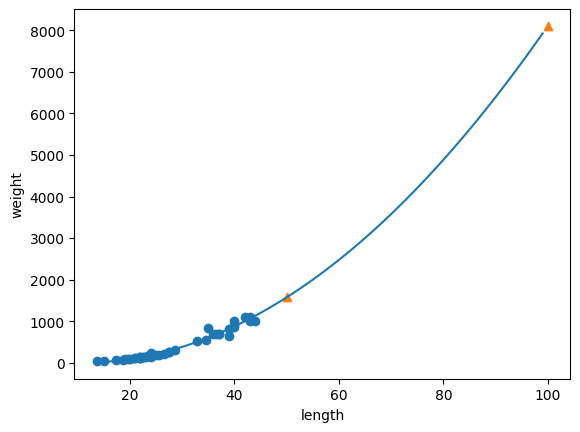

In [46]:
# 구간별 직선을 그리기 위해 15에서 49까지 정수 배열을 만듭니다.
point = np.arange(15, 100)

# 훈련 세트의 산점도
plt.scatter(train_input, train_target)

# 15에서 100까지 곡선
plt.plot(point, lr.coef_[0] * point ** 2 + lr.coef_[1] * point + lr.intercept_)
#plt.plot(point, 1.01 * point ** 2 - 21.6 * point + 116.05)


# 50, 100 농어
plt.scatter( [ [50], [100] ], [lr.predict( [[50 ** 2, 50], [100 ** 2, 100]])], marker = '^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

# 결정계수 평가

In [47]:
# 훈련세트
print(lr.score(train_poly, train_target))

# 테스트 세트
print(lr.score(test_poly, test_target))

0.9706807451768623
0.9775935108325122


훈련세트와 테스트세의 점수가 크게 높아졌다.

하지만 아직 테스트세트의 점수가 좀 더 높기에 과소적합의 문제가 남아있다.

다음 절에서 더 복잡한 모델로 이 문제를 해결해 보겠다.